# Exercícios — Inferência e Estimação

**Tema:** Estatística › Inferência e Estimação

Inferência é a arte de dizer algo sobre uma população que você nunca vai ver
inteira, usando uma amostra que você viu. Os exercícios abaixo giram em torno
de uma pergunta única: **quanto do que eu estimei é sinal e quanto é sorte?**

1. **Enunciado** → 2. **Célula de resposta** → 3. **Gabarito comentado**.

**Dificuldade:** 🟢 base · 🟡 aplicação · 🔴 síntese

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize_scalar

rng = np.random.default_rng(707)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"


def painel(titulo, **metricas):
    print(titulo)
    print("-" * max(len(titulo), 46))
    for nome, valor in metricas.items():
        rotulo = nome.replace("_", " ")
        print(f"{rotulo:<34s} {valor:>12.5f}" if isinstance(valor, (int, float, np.floating))
              else f"{rotulo:<34s} {valor:>12}")
    print()


print("ambiente pronto")

ambiente pronto


---
## Exercício 1 🟢 — Viés e consistência, medidos e não decorados

A variância amostral tem duas versões: dividindo por $n$ e por $n-1$.

1. Simule 20.000 amostras de tamanho $n = 5$ de uma $\mathcal{N}(0, 1)$.
2. Calcule as duas versões da variância em cada amostra.
3. Compare a **média das estimativas** com o valor verdadeiro ($\sigma^2 = 1$).
4. Repita com $n = 50$ e $n = 500$. O que acontece com o viés?

**Pergunta bônus:** o desvio-padrão amostral com $n-1$ é não-viesado para
$\sigma$? (Cuidado — a resposta surpreende.)

In [2]:
# --- sua resposta ---

### Gabarito 1

In [3]:
linhas = []
for n in (5, 50, 500):
    amostras = rng.normal(0, 1, size=(20_000, n))
    v_n = amostras.var(axis=1, ddof=0)
    v_n1 = amostras.var(axis=1, ddof=1)
    linhas.append({
        "n": n,
        "E[var ddof=0]": v_n.mean(), "vies_ddof0": v_n.mean() - 1,
        "E[var ddof=1]": v_n1.mean(), "vies_ddof1": v_n1.mean() - 1,
        "E[dp ddof=1]": np.sqrt(v_n1).mean(), "vies_do_dp": np.sqrt(v_n1).mean() - 1,
    })
print(pd.DataFrame(linhas).round(5).to_string(index=False))

  n  E[var ddof=0]  vies_ddof0  E[var ddof=1]  vies_ddof1  E[dp ddof=1]  vies_do_dp
  5        0.79546    -0.20454        0.99432    -0.00568       0.93778    -0.06222
 50        0.97950    -0.02050        0.99949    -0.00051       0.99468    -0.00532
500        0.99845    -0.00155        1.00045     0.00045       0.99972    -0.00028


**O que a tabela mostra:**

- Dividir por $n$ subestima a variância sistematicamente, e o viés é
  exatamente $-\sigma^2/n$: com $n=5$, erro de $-20\%$; com $n=500$, $-0{,}2\%$.
  O estimador é **viesado mas consistente** — o viés some quando $n \to \infty$.
- Dividir por $n-1$ zera o viés em **qualquer** $n$. A razão: a média amostral
  $\bar{x}$ já foi estimada dos mesmos dados, e ela é, por construção, o ponto
  que **minimiza** a soma dos quadrados. Sobrou um grau de liberdade a menos.

**A surpresa:** o desvio-padrão com $n-1$ é **viesado para baixo**, mesmo com a
variância sendo não-viesada. Motivo: $\mathbb{E}[\sqrt{X}] \neq \sqrt{\mathbb{E}[X]}$
— a raiz é côncava e a desigualdade de Jensen morde. Não-viesamento **não
sobrevive a transformações não-lineares**, e é por isso que exponenciar um
coeficiente não-viesado de regressão log não devolve algo não-viesado.

---
## Exercício 2 🟢 — Erro-padrão: a raiz de n em ação

1. Para $n \in \{10, 40, 160, 640, 2560\}$, simule 5.000 médias amostrais de
   uma população com $\sigma = 20$.
2. Meça o desvio-padrão dessas médias e compare com $\sigma/\sqrt{n}$.
3. Plote o erro-padrão contra $n$.

**Pergunta:** quanto custa cortar o erro-padrão pela metade?

In [4]:
# --- sua resposta ---

### Gabarito 2

   n  EP empírico  EP teórico σ/√n
  10        6.420            6.325
  40        3.213            3.162
 160        1.575            1.581
 640        0.782            0.791
2560        0.388            0.395


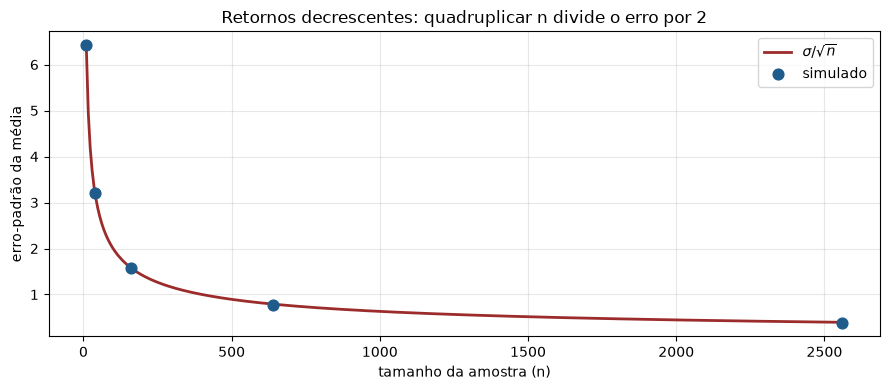

In [5]:
SIGMA = 20
ns = np.array([10, 40, 160, 640, 2560])
ep_empirico = np.array([rng.normal(50, SIGMA, (5000, n)).mean(axis=1).std(ddof=1) for n in ns])
ep_teorico = SIGMA / np.sqrt(ns)

print(pd.DataFrame({"n": ns, "EP empírico": ep_empirico.round(3),
                    "EP teórico σ/√n": ep_teorico.round(3)}).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
grade = np.linspace(10, 2560, 400)
ax.plot(grade, SIGMA / np.sqrt(grade), color=VERMELHO, lw=2, label=r"$\sigma/\sqrt{n}$")
ax.scatter(ns, ep_empirico, color=AZUL, s=60, zorder=3, label="simulado")
ax.set_xlabel("tamanho da amostra (n)"); ax.set_ylabel("erro-padrão da média")
ax.set_title("Retornos decrescentes: quadruplicar n divide o erro por 2")
ax.legend(); plt.tight_layout(); plt.show()

**Resposta:** cortar o erro-padrão pela metade custa **quatro vezes mais
dados**. Passar de $n = 640$ para $n = 2560$ — quase 2.000 coletas a mais —
derruba o erro-padrão de 0,79 para 0,40.

Essa é a economia inteira da coleta de dados em uma linha. Todo pedido de "mais
dados" tem retorno quadraticamente decrescente, e em algum ponto a variância
deixa de ser o gargalo: **viés não diminui com $n$**. Uma amostra de 1 milhão
de pessoas mal selecionadas é pior que 1.000 bem selecionadas — o erro-padrão
fica minúsculo em torno do número errado.

---
## Exercício 3 🟡 — Máxima verossimilhança na unha

Você tem 40 observações de tempo até churn (em meses), que supõe exponenciais.

1. Escreva a função de **log-verossimilhança** de $\lambda$.
2. Maximize-a numericamente com `minimize_scalar`.
3. Compare com a solução analítica $\hat{\lambda} = 1/\bar{x}$.
4. Plote a curva de log-verossimilhança marcando o máximo.
5. Estime o erro-padrão pela **curvatura** (informação de Fisher observada).

In [6]:
tempos_churn = rng.exponential(scale=14.0, size=40)
print(np.round(tempos_churn[:12], 2))

[19.3   1.38 12.   28.04  2.67 15.43 26.82 11.53  2.33  1.81 31.18 22.03]


In [7]:
# --- sua resposta ---

### Gabarito 3

MLE da taxa de churn
----------------------------------------------
lambda numerico                         0.07036
lambda analitico                        0.07036
vida media estimada meses              14.21197
erro padrao de lambda                   0.01113
IC95 vida media inf                    10.84963
IC95 vida media sup                    20.59417



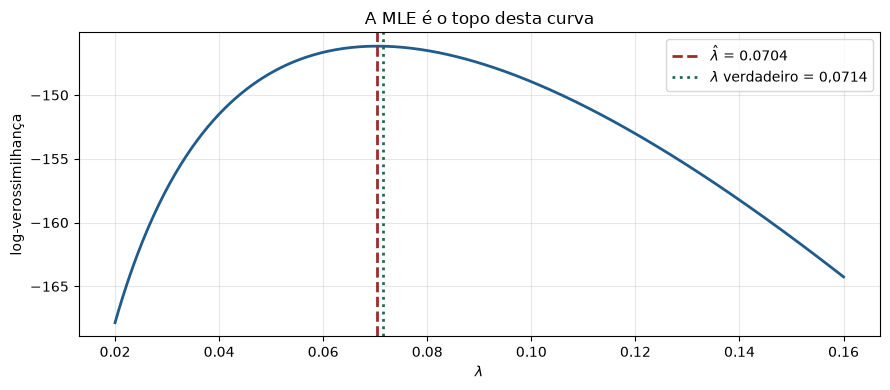

In [8]:
def log_verossimilhanca(lam, x):
    if lam <= 0:
        return -np.inf
    return len(x) * np.log(lam) - lam * x.sum()


otimo = minimize_scalar(lambda l: -log_verossimilhanca(l, tempos_churn),
                        bounds=(1e-4, 1.0), method="bounded")
lam_numerico = otimo.x
lam_analitico = 1 / tempos_churn.mean()

# informação de Fisher observada: -d²ℓ/dλ² = n/λ²  ⇒  EP = λ/√n
ep_lambda = lam_analitico / np.sqrt(len(tempos_churn))

painel("MLE da taxa de churn",
       lambda_numerico=lam_numerico, lambda_analitico=lam_analitico,
       vida_media_estimada_meses=1 / lam_analitico,
       erro_padrao_de_lambda=ep_lambda,
       IC95_vida_media_inf=1 / (lam_analitico + 1.96 * ep_lambda),
       IC95_vida_media_sup=1 / (lam_analitico - 1.96 * ep_lambda))

grade_lam = np.linspace(0.02, 0.16, 400)
curva = [log_verossimilhanca(l, tempos_churn) for l in grade_lam]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(grade_lam, curva, color=AZUL, lw=2)
ax.axvline(lam_analitico, color=VERMELHO, lw=2, ls="--",
           label=fr"$\hat\lambda$ = {lam_analitico:.4f}")
ax.axvline(1 / 14.0, color=VERDE, lw=2, ls=":", label=r"$\lambda$ verdadeiro = 0,0714")
ax.set_xlabel(r"$\lambda$"); ax.set_ylabel("log-verossimilhança")
ax.set_title("A MLE é o topo desta curva")
ax.legend(); plt.tight_layout(); plt.show()

**A ideia da MLE em uma frase:** entre todos os valores possíveis do parâmetro,
escolha aquele que torna **os dados que você viu** os mais prováveis de terem
sido gerados.

**A curvatura é a precisão.** A segunda derivada da log-verossimilhança no
máximo é a **informação de Fisher observada**: pico estreito e pontudo ⇒ muita
informação ⇒ erro-padrão pequeno. Pico achatado ⇒ muitos valores de $\lambda$
explicam os dados quase igualmente bem ⇒ estimativa frouxa. Todo erro-padrão
reportado por `statsmodels` ou `sklearn` sai daí.

**Detalhe que vale ouro:** o IC da vida média foi obtido invertendo os limites
do IC de $\lambda$ — e por isso ele é **assimétrico**. Construir o IC no
parâmetro onde a verossimilhança é mais simétrica e depois transformar é quase
sempre melhor do que usar `±1,96 EP` na escala final.

---
## Exercício 4 🟡 — Bootstrap contra a fórmula

Você quer um intervalo de confiança para a **mediana** do ticket de compra —
uma estatística sem fórmula fechada amigável.

1. Gere 300 tickets log-normais.
2. Construa um IC 95% para a mediana por **bootstrap percentil** (10.000
   reamostragens).
3. Construa também um IC para a **média** por bootstrap e pela fórmula do TLC.
4. Compare: onde os dois métodos concordam e onde divergem?

In [9]:
# --- sua resposta ---

### Gabarito 4

Ticket — n = 300
----------------------------------------------
mediana amostral                      169.83824
media amostral                        239.74763

IC95 da MEDIANA (bootstrap):  [  151.97,   195.52]
IC95 da MÉDIA   (bootstrap):  [  213.02,   271.09]
IC95 da MÉDIA   (fórmula TLC):[  210.82,   268.67]

assimetria da distribuição bootstrap da média: +0.263


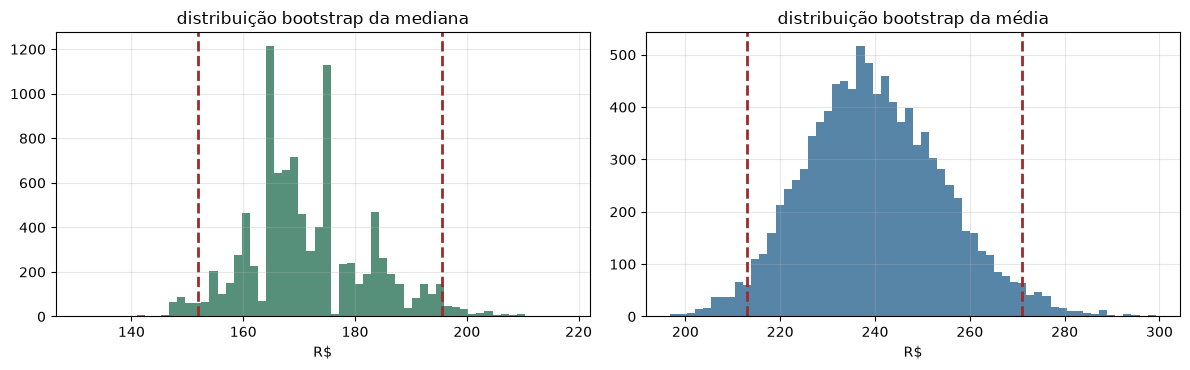

In [10]:
tickets = rng.lognormal(np.log(180), 0.8, size=300)
B = 10_000
indices = rng.integers(0, len(tickets), size=(B, len(tickets)))
reamostras = tickets[indices]

boot_mediana = np.median(reamostras, axis=1)
boot_media = reamostras.mean(axis=1)

ic_med_boot = np.percentile(boot_mediana, [2.5, 97.5])
ic_mean_boot = np.percentile(boot_media, [2.5, 97.5])
ep_tlc = tickets.std(ddof=1) / np.sqrt(len(tickets))
ic_mean_tlc = tickets.mean() + np.array([-1.96, 1.96]) * ep_tlc

painel("Ticket — n = 300",
       mediana_amostral=np.median(tickets), media_amostral=tickets.mean())
print(f"IC95 da MEDIANA (bootstrap):  [{ic_med_boot[0]:8.2f}, {ic_med_boot[1]:8.2f}]")
print(f"IC95 da MÉDIA   (bootstrap):  [{ic_mean_boot[0]:8.2f}, {ic_mean_boot[1]:8.2f}]")
print(f"IC95 da MÉDIA   (fórmula TLC):[{ic_mean_tlc[0]:8.2f}, {ic_mean_tlc[1]:8.2f}]")
print(f"\nassimetria da distribuição bootstrap da média: {stats.skew(boot_media):+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, boot, ic, nome, cor in [(axes[0], boot_mediana, ic_med_boot, "mediana", VERDE),
                                (axes[1], boot_media, ic_mean_boot, "média", AZUL)]:
    ax.hist(boot, bins=60, color=cor, alpha=0.75)
    ax.axvline(ic[0], color=VERMELHO, lw=2, ls="--")
    ax.axvline(ic[1], color=VERMELHO, lw=2, ls="--")
    ax.set_title(f"distribuição bootstrap da {nome}")
    ax.set_xlabel("R$")
plt.tight_layout(); plt.show()

**Onde concordam:** para a média, bootstrap e fórmula do TLC dão intervalos
muito parecidos — com $n = 300$ o TLC já operou.

**Onde o bootstrap ganha:** para a **mediana**, não há fórmula elementar. O
bootstrap dá o intervalo sem que você precise derivar nada — só reamostrar.

**O detalhe fino:** a distribuição bootstrap da média ainda é levemente
assimétrica à direita (a cauda log-normal), e o IC percentil captura isso;
a fórmula `±1,96 EP` é simétrica por construção e não captura.

> **O que o bootstrap NÃO conserta:** ele reamostra **a sua amostra**. Se a
> amostra for enviesada — coletada só de clientes ativos, só de uma região —
> o bootstrap reproduz fielmente o viés com um intervalo estreito e
> tranquilizador. Bootstrap trata **variância**, nunca **viés de seleção**.

---
## Exercício 5 🟡 — O que "95% de confiança" realmente significa

A interpretação errada ("há 95% de chance do parâmetro estar neste intervalo")
é quase universal. Vamos medir a interpretação certa.

1. Simule 200 experimentos, cada um com $n = 30$ de uma $\mathcal{N}(100, 15)$.
2. Construa o IC 95% da média em cada um.
3. Conte quantos contêm o verdadeiro 100.
4. Plote os primeiros 60 intervalos, destacando os que erram.

In [11]:
# --- sua resposta ---

### Gabarito 5

Cobertura empírica do IC 95%
----------------------------------------------
experimentos                          200.00000
cobriram                              193.00000
cobertura                               0.96500
esperado                                0.95000



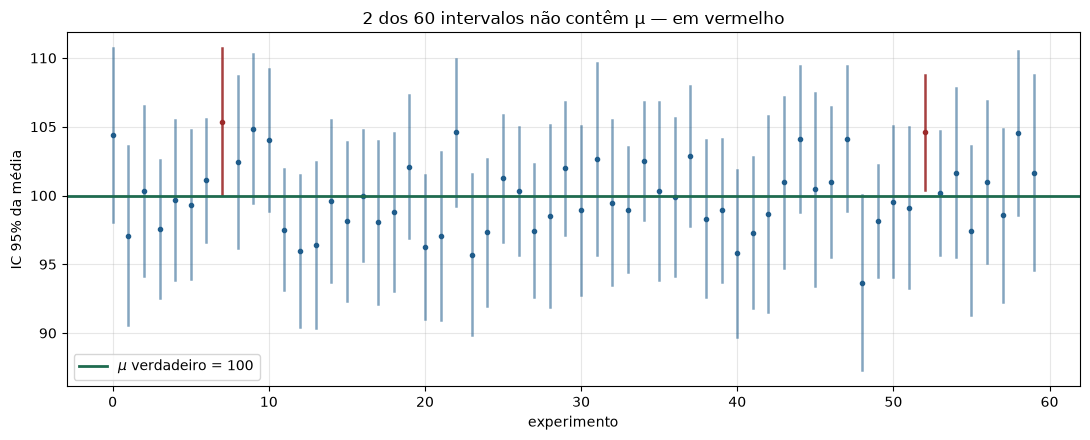

In [12]:
MU, SIGMA_POP, N_EXP, n = 100, 15, 200, 30
amostras = rng.normal(MU, SIGMA_POP, size=(N_EXP, n))
medias = amostras.mean(axis=1)
eps = amostras.std(axis=1, ddof=1) / np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n - 1)
inf, sup = medias - t_crit * eps, medias + t_crit * eps
cobre = (inf <= MU) & (MU <= sup)

painel("Cobertura empírica do IC 95%",
       experimentos=float(N_EXP), cobriram=float(cobre.sum()),
       cobertura=cobre.mean(), esperado=0.95)

fig, ax = plt.subplots(figsize=(11, 4.5))
k = 60
for i in range(k):
    cor = AZUL if cobre[i] else VERMELHO
    ax.plot([i, i], [inf[i], sup[i]], color=cor, lw=1.8,
            alpha=0.9 if not cobre[i] else 0.55)
    ax.plot(i, medias[i], "o", color=cor, ms=3)
ax.axhline(MU, color=VERDE, lw=2, label=r"$\mu$ verdadeiro = 100")
ax.set_xlabel("experimento"); ax.set_ylabel("IC 95% da média")
ax.set_title(f"{(~cobre[:k]).sum()} dos {k} intervalos não contêm μ — em vermelho")
ax.legend(); plt.tight_layout(); plt.show()

**A interpretação correta é sobre o procedimento, não sobre o intervalo:**
se você repetir a coleta e o cálculo indefinidamente, 95% dos intervalos
construídos assim conterão o parâmetro. Do **seu** intervalo específico, já
calculado, ou ele contém $\mu$ ou não — não há probabilidade envolvida, porque
$\mu$ é fixo e o intervalo também já é.

A frase "há 95% de chance de $\mu$ estar aqui" é **bayesiana**, e exige um
intervalo de credibilidade construído a partir de uma posteriori — o assunto do
módulo 05. Frequentista e bayesiano respondem perguntas diferentes; o problema
é reportar um e interpretar como o outro.

**Consequência prática:** ver um IC que exclui zero não significa "95% de
certeza de que o efeito existe". Significa "sob $H_0$, dados assim seriam
incomuns" — nada mais.

---
## Exercício 6 🔴 — Quando o IC do TLC quebra

O IC baseado no TLC pressupõe que a média amostral é aproximadamente normal.
Vamos encontrar onde essa promessa falha.

1. Meça a **cobertura real** do IC 95% da média, com $n \in \{10, 30, 100\}$,
   para três populações: normal, exponencial e log-normal com $\sigma = 2$.
2. Monte uma tabela de cobertura.
3. Diga em quais células o intervalo mente e por quê.

In [13]:
# --- sua resposta ---

### Gabarito 6

Cobertura real de um IC nominal de 95%:

                   n=10  n=30  n=100
população                           
normal(100,15)     94.7  95.0   94.6
exponencial(m=10)  89.4  93.0   94.2
lognormal(σ=2)     57.5  65.1   74.4


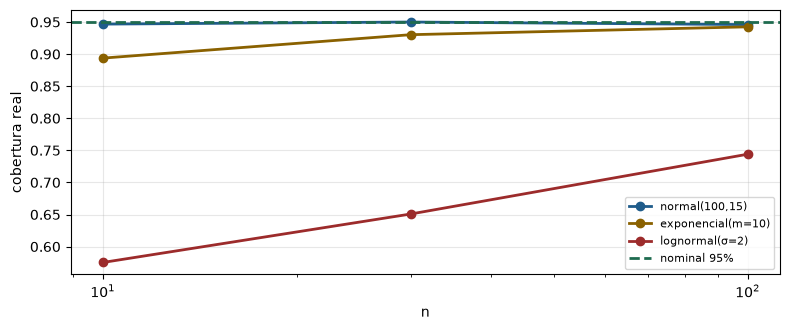

In [14]:
POPULACOES = {
    "normal(100,15)":   (lambda tam: rng.normal(100, 15, tam), 100.0),
    "exponencial(m=10)": (lambda tam: rng.exponential(10, tam), 10.0),
    "lognormal(σ=2)":   (lambda tam: rng.lognormal(0, 2, tam), np.exp(0 + 2**2 / 2)),
}
REPS = 4000

linhas = []
for nome, (gera, verdadeiro) in POPULACOES.items():
    linha = {"população": nome}
    for n in (10, 30, 100):
        am = gera((REPS, n))
        m, ep = am.mean(axis=1), am.std(axis=1, ddof=1) / np.sqrt(n)
        tc = stats.t.ppf(0.975, n - 1)
        cob = ((m - tc * ep <= verdadeiro) & (verdadeiro <= m + tc * ep)).mean()
        linha[f"n={n}"] = cob
    linhas.append(linha)

tabela = pd.DataFrame(linhas).set_index("população")
print("Cobertura real de um IC nominal de 95%:\n")
print((tabela * 100).round(1).to_string())

fig, ax = plt.subplots(figsize=(8, 3.4))
for nome, cor in zip(tabela.index, [AZUL, AMBAR, VERMELHO]):
    ax.plot([10, 30, 100], tabela.loc[nome].to_numpy(), "o-", color=cor, lw=2, label=nome)
ax.axhline(0.95, color=VERDE, ls="--", lw=2, label="nominal 95%")
ax.set_xscale("log"); ax.set_xlabel("n"); ax.set_ylabel("cobertura real")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

**Onde o intervalo mente:** na log-normal com $\sigma = 2$ — assimetria
extrema — a cobertura fica muito abaixo de 95% mesmo com $n = 100$. O rótulo
diz 95%, a realidade entrega bem menos. Você está **mais errado do que pensa**,
e nada no output do seu código avisa.

**A raiz do problema:** com cauda pesada, a média amostral e o desvio-padrão
amostral são **correlacionados** — amostras que pegam um valor gigante têm
média alta *e* desvio alto, o que infla o intervalo na direção errada. A
suposição de independência entre numerador e denominador da estatística $t$
quebra.

**O que fazer:** transformar (trabalhar em log), usar bootstrap BCa, ou mudar o
alvo — se a distribuição é tão assimétrica, a **mediana** provavelmente é a
quantidade que interessa de verdade ao negócio.

---
## Exercício 7 🔴 — Desafio: sua própria função de inferência

Escreva `estima(x, estatistica, metodo="bootstrap", nivel=0.95)` que devolva
estimativa pontual, erro-padrão, IC e um diagnóstico. Requisitos:

1. aceitar qualquer estatística (`np.mean`, `np.median`, uma lambda de quantil);
2. suportar `metodo` em `{"bootstrap", "jackknife"}`;
3. incluir a correção **BCa** no bootstrap (viés + aceleração);
4. avisar quando a distribuição bootstrap for muito assimétrica.

In [15]:
# --- sua resposta ---

### Gabarito 7

In [16]:
def estima(x, estatistica=np.mean, metodo="bootstrap", nivel=0.95, B=8000, semente=0):
    x = np.asarray(x, dtype=float)
    n = len(x)
    ponto = estatistica(x)
    alfa = 1 - nivel
    gerador = np.random.default_rng(semente)

    # jackknife serve tanto de método quanto de insumo da aceleração do BCa
    jack = np.array([estatistica(np.delete(x, i)) for i in range(n)])
    jack_media = jack.mean()

    if metodo == "jackknife":
        ep = np.sqrt((n - 1) / n * ((jack - jack_media) ** 2).sum())
        z = stats.norm.ppf(1 - alfa / 2)
        ic = (ponto - z * ep, ponto + z * ep)
        assimetria = 0.0
    else:
        idx = gerador.integers(0, n, size=(B, n))
        boot = np.array([estatistica(linha) for linha in x[idx]])
        ep = boot.std(ddof=1)
        assimetria = stats.skew(boot)

        # BCa: z0 corrige o viés de mediana, "a" corrige a assimetria
        z0 = stats.norm.ppf(np.clip((boot < ponto).mean(), 1e-6, 1 - 1e-6))
        num = ((jack_media - jack) ** 3).sum()
        den = 6 * (((jack_media - jack) ** 2).sum() ** 1.5)
        a = num / den if den != 0 else 0.0

        def ajusta(p):
            z = stats.norm.ppf(p)
            return stats.norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))

        ic = tuple(np.percentile(boot, [100 * ajusta(alfa / 2),
                                        100 * ajusta(1 - alfa / 2)]))

    avisos = []
    if abs(assimetria) > 0.5:
        avisos.append(f"distribuição bootstrap assimétrica ({assimetria:+.2f}) — "
                      "não use ±1,96·EP, o IC BCa acima já corrige")
    if n < 30:
        avisos.append(f"n = {n} é pequeno; a cobertura real pode ficar abaixo do nominal")

    print(f"estimativa   {ponto:>12.4f}")
    print(f"erro-padrão  {ep:>12.4f}   ({metodo})")
    print(f"IC {nivel:.0%}       [{ic[0]:.4f}, {ic[1]:.4f}]")
    for a_ in avisos:
        print(f"  ! {a_}")
    print()
    return {"ponto": ponto, "ep": ep, "ic": ic, "avisos": avisos}


print(">>> média de tickets log-normais")
_ = estima(tickets, np.mean)
print(">>> mediana dos mesmos tickets")
_ = estima(tickets, np.median)
print(">>> percentil 95 (a métrica de latência p95)")
_ = estima(tickets, lambda v: np.percentile(v, 95))
print(">>> média por jackknife, para comparar")
_ = estima(tickets, np.mean, metodo="jackknife")

>>> média de tickets log-normais


estimativa       239.7476
erro-padrão       14.7512   (bootstrap)
IC 95%       [215.7859, 275.8922]

>>> mediana dos mesmos tickets
estimativa       169.8382
erro-padrão       11.1280   (bootstrap)
IC 95%       [150.5224, 195.5156]
  ! distribuição bootstrap assimétrica (+0.51) — não use ±1,96·EP, o IC BCa acima já corrige

>>> percentil 95 (a métrica de latência p95)


estimativa       637.9774
erro-padrão       57.2937   (bootstrap)
IC 95%       [544.2502, 828.3943]
  ! distribuição bootstrap assimétrica (+0.95) — não use ±1,96·EP, o IC BCa acima já corrige

>>> média por jackknife, para comparar
estimativa       239.7476
erro-padrão       14.7577   (jackknife)
IC 95%       [210.8231, 268.6722]



**Por que o BCa e não o percentil simples:** o bootstrap percentil supõe que a
distribuição bootstrap é centrada e simétrica em torno da estimativa. Quando
não é — quantis extremos, razões, estatísticas limitadas — o intervalo fica
deslocado. O BCa corrige duas coisas:

- $z_0$ (**bias correction**): quanto a distribuição bootstrap está deslocada
  em relação à estimativa observada;
- $a$ (**aceleração**): quanto o erro-padrão varia com o valor do parâmetro,
  estimada pelo jackknife.

**Sobre o p95:** o intervalo dele é sempre largo — quantis de cauda dependem de
poucas observações. É exatamente por isso que dashboards de latência p95/p99
oscilam tanto de dia para dia: boa parte da variação é ruído amostral, não
degradação do serviço. Reportar p99 sem intervalo é convidar o time a caçar
fantasmas.

---
## Fechamento

- **Viés e variância são erros diferentes.** Mais dados matam variância e não
  tocam em viés.
- **Não-viesamento não sobrevive a transformação não-linear.**
- **Erro-padrão cai com $\sqrt{n}$**: metade do erro custa 4× o orçamento.
- **A curvatura da verossimilhança é a precisão** — é de lá que vem todo EP.
- **Bootstrap resolve variância, não viés de seleção.**
- **"95% de confiança" é uma propriedade do procedimento**, não do seu intervalo.

→ Próximo módulo: **Testes de Hipótese** — transformar essas estimativas em
decisões, com uma régua explícita para o erro que você aceita cometer.